# Synthetic blind ptychography: 62.5% overlap, $\eta=0.05$


In [1]:
# ruff: noqa: E402 -- project path and environment must be configured first.
import os
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import sys
from time import perf_counter
from tempfile import gettempdir

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("MPLCONFIGDIR", str(Path(gettempdir()) / "magpie-matplotlib"))
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb, to_rgb
import numpy as np
import ptychi.api as api

from algorithms.gm_rpie import run_gm_rpie
from algorithms.lsqml import LSQMLHyperparameters, run_lsqml
from algorithms.magpie import run_gm_magpie
from algorithms.rpie import run_rpie
from utils.common import configure_ptychi_device
from utils.reconstruction import make_frozen_amplitude_mse_evaluator
from utils.result_archive import save_synthetic_notebook_results
from utils.synthetic import (
    ExperimentConfig,
    build_synthetic_dataset,
    registered_object_truth_and_mask,
    score_blind_reconstruction,
)


## Shared settings


In [14]:
EXPERIMENT_NAME = "synthetic_overlap_0625_eta_0p05"
NOTEBOOK_PATH = (
    PROJECT_ROOT / "examples" / "synthetic" / f"{EXPERIMENT_NAME}.ipynb"
)
RESULTS_ROOT = PROJECT_ROOT / "results" / "notebook_exports" / "synthetic_overlap" / EXPERIMENT_NAME
RUN_STARTED_UTC = datetime.now(timezone.utc)
RUN_ID = RUN_STARTED_UTC.strftime("%Y%m%dT%H%M%S_%fZ")

NUM_EPOCHS = 3000
REPORT_EVERY = 20
INCLUDE_INITIAL_METRICS = True
FROZEN_METRIC_EPS = 1e-7
RECONSTRUCTION_SEED = 21

BATCH_SIZE = 81
OBJECT_EXTRA_PIXELS = 10
OBJECT_STEP_SIZE = 1.0
PROBE_STEP_SIZE = 1.0
REMOVE_OBJECT_PROBE_AMBIGUITY = True
TRUTH_PROBE_DEFOCUS_M = -7e-4
INITIAL_PROBE_DEFOCUS_M = -6e-4

dataset_cfg = ExperimentConfig(
    overlap_ratio=0.625,
    position_jitter_px=4.0,
    position_seed=42,
    poisson_eta=0.05,
    detector_centered_data=True,
    data_seed=42,
    truth_probe_defocus_m=TRUTH_PROBE_DEFOCUS_M,
    initial_probe_defocus_m=INITIAL_PROBE_DEFOCUS_M,
)
shared_cfg = replace(
    dataset_cfg,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    object_extra_pixels=OBJECT_EXTRA_PIXELS,
    reconstruction_seed=RECONSTRUCTION_SEED,
    object_step_size=OBJECT_STEP_SIZE,
    probe_step_size=PROBE_STEP_SIZE,
    remove_object_probe_ambiguity=REMOVE_OBJECT_PROBE_AMBIGUITY,
)

METHOD_ORDER = ("rPIE", "LSQML", "GM-rPIE", "GM-MAGPIE")
METHOD_FILE_STEMS = {
    "rPIE": "rpie",
    "LSQML": "lsqml",
    "GM-rPIE": "gm_rpie",
    "GM-MAGPIE": "gm_magpie",
}
METHOD_COLORS = {
    "rPIE": "#55A868",
    "LSQML": "#4C72B0",
    "GM-rPIE": "#C44E52",
    "GM-MAGPIE": "#DD8452",
}

FROZEN_NOISY_KEY = "frozen_noisy_amplitude_mse"
FROZEN_NOISELESS_KEY = "frozen_noiseless_amplitude_mse"
FROZEN_METRIC_KEYS = (FROZEN_NOISY_KEY, FROZEN_NOISELESS_KEY)
TRUTH_METRIC_KEYS = (
    "phase_rmse_rad",
    "object_nmse",
    "object_magnitude_nrmse",
    "probe_nmse",
)
SAMPLED_METRIC_KEYS = (*TRUTH_METRIC_KEYS, *FROZEN_METRIC_KEYS)
METRIC_DEFINITIONS = {
    "online_preupdate_residual": (
        "Pty-Chi online loss evaluated from each minibatch prediction before "
        "that minibatch update; one aggregate value per epoch."
    ),
    FROZEN_NOISY_KEY: (
        "All-frame mean squared amplitude error against the fixed noisy "
        f"intensities, evaluated without updates using sqrt(I + {FROZEN_METRIC_EPS:g})."
    ),
    FROZEN_NOISELESS_KEY: (
        "All-frame mean squared amplitude error against the matching fixed "
        f"noiseless intensities, evaluated without updates using sqrt(I + {FROZEN_METRIC_EPS:g})."
    ),
    "phase_rmse_rad": (
        "Truth-weighted object phase RMSE in radians on the registered "
        "illuminated support after blind-gauge alignment."
    ),
    "object_nmse": (
        "Complex object NMSE on the registered illuminated support after "
        "blind-gauge alignment."
    ),
    "object_magnitude_nrmse": (
        "Object-magnitude normalized RMSE on the registered illuminated support."
    ),
    "probe_nmse": (
        "Complex probe NMSE after applying the object-derived reciprocal "
        "blind gauge and removing the remaining global exit-wave phase."
    ),
}

if NUM_EPOCHS < 1 or REPORT_EVERY < 1:
    raise ValueError("NUM_EPOCHS and REPORT_EVERY must be positive.")

results = {}
runtimes_seconds = {}
method_run_parameters = {}


## Helpers


In [15]:
def blend_with_white(color, white_fraction=0.55):
    rgb = np.asarray(to_rgb(color), dtype=np.float64)
    return tuple((1.0 - white_fraction) * rgb + white_fraction)


PANEL_FRAME_COLORS = {
    "Truth": "#BDBDBD",
    **{
        method: blend_with_white(color)
        for method, color in METHOD_COLORS.items()
    },
}


def robust_limits(values, percentiles, *, nonnegative=False):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return 0.0, 1.0
    low, high = (float(value) for value in np.percentile(finite, percentiles))
    if nonnegative:
        low = max(0.0, low)
    if high <= low:
        high = low + max(1e-6, 1e-3 * max(abs(low), 1.0))
    return low, high


def complex_to_rgb(field, magnitude_max, *, gamma=0.6):
    field = np.asarray(field).squeeze()
    if field.ndim != 2:
        raise ValueError(f"Expected a 2D complex field, got {field.shape}.")
    magnitude = np.abs(field)
    phase = np.angle(field)
    finite = np.isfinite(magnitude) & np.isfinite(phase)
    hue = np.mod((phase + np.pi) / (2.0 * np.pi), 1.0)
    value = np.zeros_like(magnitude, dtype=np.float32)
    value[finite] = np.clip(magnitude[finite] / magnitude_max, 0.0, 1.0) ** gamma
    rgb = hsv_to_rgb(np.stack((hue, np.ones_like(hue), value), axis=-1))
    rgb[~finite] = 0.0
    return np.asarray(rgb, dtype=np.float32)


def valid_dyadic_levels(height, width):
    levels = 1
    while height % 2 == 0 and width % 2 == 0 and min(height, width) >= 2:
        height //= 2
        width //= 2
        levels += 1
    return levels


def make_progress_callback(method_name):
    def report(epoch, _online_residual, metrics):
        residual = metrics[FROZEN_NOISY_KEY]
        print(
            f"\r{method_name}: epoch {epoch}/{NUM_EPOCHS}, "
            f"frozen MSE={residual:.3e}",
            end="",
            flush=True,
        )

    return report


def reconstruction_kwargs(method_name):
    return {
        "seed": RECONSTRUCTION_SEED,
        "error_stride": REPORT_EVERY,
        "include_initial_metrics": INCLUDE_INITIAL_METRICS,
        "progress_callback": make_progress_callback(method_name),
        "task_metric_function": frozen_checkpoint_evaluator,
        "final_metric_function": frozen_checkpoint_evaluator,
    }


def validate_result(method_name, result):
    expected_epochs = np.asarray(
        sorted(
            {
                0,
                1,
                NUM_EPOCHS,
                *range(REPORT_EVERY, NUM_EPOCHS + 1, REPORT_EVERY),
            }
        ),
        dtype=np.int64,
    )
    if result.residual_history.shape != (NUM_EPOCHS,):
        raise ValueError(f"{method_name}: unexpected residual-history shape.")
    if not np.all(np.isfinite(result.residual_history)):
        raise ValueError(f"{method_name}: residual history is not finite.")
    np.testing.assert_array_equal(result.metric_epochs, expected_epochs)
    if set(result.metric_history) != set(SAMPLED_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected metric names.")
    for metric_name, values in result.metric_history.items():
        if values.shape != expected_epochs.shape or not np.all(
            np.isfinite(values)
        ):
            raise ValueError(f"{method_name}: invalid {metric_name} history.")
    if set(result.final_metrics) != set(FROZEN_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected final metrics.")
    if not np.all(np.isfinite(result.object)):
        raise ValueError(f"{method_name}: object contains nonfinite values.")
    if not np.all(np.isfinite(result.probe)):
        raise ValueError(f"{method_name}: probe contains nonfinite values.")

def store_result(method_name, result, runtime_seconds, parameters):
    validate_result(method_name, result)
    runtime_seconds = float(runtime_seconds)
    if not np.isfinite(runtime_seconds) or runtime_seconds <= 0:
        raise ValueError(f"{method_name}: runtime must be finite and positive.")
    results[method_name] = result
    runtimes_seconds[method_name] = runtime_seconds
    method_run_parameters[method_name] = dict(parameters)
    for mapping_name in ("scores", "aligned_objects", "aligned_probes"):
        mapping = globals().get(mapping_name)
        if isinstance(mapping, dict):
            mapping.pop(method_name, None)
    print(f"\n{method_name} finished in {runtime_seconds / 60.0:.2f} min")


def completed_methods():
    methods = [method for method in METHOD_ORDER if method in results]
    if not methods:
        raise RuntimeError("Run at least one method cell first.")
    missing = [method for method in METHOD_ORDER if method not in results]
    if missing:
        print("Not run: " + ", ".join(missing))
    return methods


## Data


In [16]:
device = configure_ptychi_device(backend="mps")
dataset = build_synthetic_dataset(dataset_cfg)
noiseless_dataset = build_synthetic_dataset(
    replace(dataset_cfg, poisson_eta=0.0)
)
frozen_checkpoint_evaluator = make_frozen_amplitude_mse_evaluator(
    {
        FROZEN_NOISY_KEY: dataset.data,
        FROZEN_NOISELESS_KEY: noiseless_dataset.data,
    },
    batch_size=BATCH_SIZE,
    eps=FROZEN_METRIC_EPS,
)

results.clear()
runtimes_seconds.clear()
method_run_parameters.clear()
for stale_name in (
    "scores",
    "aligned_objects",
    "aligned_probes",
    "registered_truth",
    "illuminated",
):
    globals().pop(stale_name, None)

print(f"device={device.value}, patterns={len(dataset.data)}")


device=gpu, patterns=324


The method cells below declare the fixed hyperparameters for this comparison. The alphas and initial-probe defocus differ between overlap conditions. Edit these values before a new run when exploring another setting; the saved reference tables describe the original configuration.


## rPIE


In [17]:
RPIE_ALPHAS = (0.1, 0.1)

rpie_cfg = replace(
    shared_cfg,
    object_alpha=RPIE_ALPHAS[0],
    probe_alpha=RPIE_ALPHAS[1],
)
started = perf_counter()
rpie_result = run_rpie(
    dataset,
    rpie_cfg,
    device,
    **reconstruction_kwargs("rPIE"),
)
store_result(
    "rPIE",
    rpie_result,
    perf_counter() - started,
    {"runner": "run_rpie", "config": rpie_cfg},
)


rPIE: epoch 3000/3000, frozen MSE=2.111e-02
rPIE finished in 3.17 min


## LSQML


In [18]:
LSQML_SCALER = 1

lsqml_hyperparameters = LSQMLHyperparameters(
    object_step_size_scaler=LSQML_SCALER,
    probe_step_size_scaler=LSQML_SCALER,
    noise_model=api.NoiseModels.POISSON,
)

started = perf_counter()
lsqml_result = run_lsqml(
    dataset,
    shared_cfg,
    device,
    hyperparameters=lsqml_hyperparameters,
    **reconstruction_kwargs("LSQML"),
)
store_result(
    "LSQML",
    lsqml_result,
    perf_counter() - started,
    {
        "runner": "run_lsqml",
        "config": shared_cfg,
        "hyperparameters": lsqml_hyperparameters,
    },
)


LSQML: epoch 3000/3000, frozen MSE=2.407e-02
LSQML finished in 5.45 min


## GM-rPIE


In [19]:
GM_RPIE_ALPHAS = (0.01, 0.01)

gm_rpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_RPIE_ALPHAS[0],
    probe_alpha=GM_RPIE_ALPHAS[1],
)
started = perf_counter()
gm_rpie_result = run_gm_rpie(
    dataset,
    gm_rpie_cfg,
    device,
    **reconstruction_kwargs("GM-rPIE"),
)
store_result(
    "GM-rPIE",
    gm_rpie_result,
    perf_counter() - started,
    {
        "runner": "run_gm_rpie",
        "config": gm_rpie_cfg,
        "effective_multigrid_levels": 1,
    },
)


GM-rPIE: epoch 3000/3000, frozen MSE=1.897e-02
GM-rPIE finished in 4.67 min


## GM-MAGPIE


In [31]:
GM_MAGPIE_ALPHAS = (0.02, 0.01)

gm_magpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_MAGPIE_ALPHAS[0],
    probe_alpha=GM_MAGPIE_ALPHAS[1],
)
started = perf_counter()
gm_magpie_result = run_gm_magpie(
    dataset,
    gm_magpie_cfg,
    device,
    **reconstruction_kwargs("GM-MAGPIE"),
)
store_result(
    "GM-MAGPIE",
    gm_magpie_result,
    perf_counter() - started,
    {
        "runner": "run_gm_magpie",
        "config": gm_magpie_cfg,
        "requested_multigrid_levels": None,
        "effective_multigrid_levels": valid_dyadic_levels(
            *dataset.probe_init.shape[-2:]
        ),
    },
)


GM-MAGPIE: epoch 3000/3000, frozen MSE=1.724e-02
GM-MAGPIE finished in 5.29 min


## Scores


In [32]:
methods = completed_methods()
scores = {}
aligned_objects = {}
aligned_probes = {}
registered_truth = None
illuminated = None

for method_name in methods:
    result = results[method_name]
    metrics, object_aligned, probe_aligned = score_blind_reconstruction(
        result.object,
        result.probe,
        dataset,
    )
    scores[method_name] = metrics
    aligned_objects[method_name] = object_aligned
    aligned_probes[method_name] = probe_aligned

    method_truth, method_mask = registered_object_truth_and_mask(
        result.object,
        dataset,
    )
    if registered_truth is None:
        registered_truth = method_truth
        illuminated = method_mask
    else:
        np.testing.assert_array_equal(method_truth, registered_truth)
        np.testing.assert_array_equal(method_mask, illuminated)

print(
    f"{'method':<12} {'frozen MSE':>14} {'phase RMSE':>14} "
    f"{'object NMSE':>14} {'probe NMSE':>14}"
)
print("-" * 72)
for method_name in methods:
    result = results[method_name]
    print(
        f"{method_name:<12} "
        f"{result.final_metrics[FROZEN_NOISY_KEY]:>14.3e} "
        f"{scores[method_name]['phase_rmse_rad']:>14.3e} "
        f"{scores[method_name]['object_nmse']:>14.3e} "
        f"{scores[method_name]['probe_nmse']:>14.3e}"
    )


method           frozen MSE     phase RMSE    object NMSE     probe NMSE
------------------------------------------------------------------------
rPIE              2.111e-02      1.715e-01      3.981e-02      3.623e-01
LSQML             2.407e-02      1.937e-01      5.065e-02      3.377e-01
GM-rPIE           1.897e-02      1.395e-01      2.944e-02      3.728e-02
GM-MAGPIE         1.724e-02      1.359e-01      2.778e-02      2.075e-02


## Save numeric notebook-run archive


After **Restart Kernel and Run All Cells**, the next cell requires all four validated methods, scores, alignments, and runtimes. It runs before the optional plotting cells and writes a new immutable directory beneath `results/notebook_exports/synthetic_overlap/synthetic_overlap_0625_eta_0p05/`; it never overwrites an earlier run. The archive contains exact complex pixel values for every raw and gauge-aligned object/probe reconstruction, exact noisy/noiseless inputs and truth arrays, every metric and residual value, full-precision runtimes, method and environment metadata, source/input hashes, validation results, and checksums. It deliberately saves no rendered figures: magnitude, phase, and other displays can be derived later from the complex arrays. This is a complete archive of one notebook run.


In [36]:
source_paths = {
    str(path.relative_to(PROJECT_ROOT)): path
    for path in sorted((PROJECT_ROOT / "src").rglob("*.py"))
    if not any(part.startswith(".") or part == "__pycache__"
               for part in path.relative_to(PROJECT_ROOT).parts)
}
for relative_path in (
    "pyproject.toml",
    "assets/baboon.tiff",
    "assets/cameraman.tif",
):
    source_paths[relative_path] = PROJECT_ROOT / relative_path

saved_run_dir = save_synthetic_notebook_results(
    output_root=RESULTS_ROOT,
    project_root=PROJECT_ROOT,
    experiment_name=EXPERIMENT_NAME,
    notebook_path=NOTEBOOK_PATH,
    run_started_utc=RUN_STARTED_UTC,
    run_id=RUN_ID,
    dataset_config=dataset_cfg,
    shared_config=shared_cfg,
    method_order=METHOD_ORDER,
    method_file_stems=METHOD_FILE_STEMS,
    method_parameters=method_run_parameters,
    results=results,
    runtimes_seconds=runtimes_seconds,
    scores=scores,
    aligned_objects=aligned_objects,
    aligned_probes=aligned_probes,
    registered_truth=registered_truth,
    illuminated=illuminated,
    dataset=dataset,
    noiseless_dataset=noiseless_dataset,
    metric_report_every=REPORT_EVERY,
    include_initial_metrics=INCLUDE_INITIAL_METRICS,
    frozen_metric_eps=FROZEN_METRIC_EPS,
    sampled_metric_keys=SAMPLED_METRIC_KEYS,
    final_metric_keys=FROZEN_METRIC_KEYS,
    truth_metric_keys=TRUTH_METRIC_KEYS,
    device=device,
    source_paths=source_paths,
    metric_definitions=METRIC_DEFINITIONS,
    timing_notes=(
        "Each method runtime spans task construction, 3,000 reconstruction "
        "epochs, and sampled frozen/truth metrics. The timer is perf_counter; "
        "there is no explicit device synchronization or warm-up."
    ),
)
print(f"Saved and verified complete run: {saved_run_dir}")


Saved and verified complete run: <original-project>/results/notebook_exports/synthetic_overlap_0625_eta_0p05/20260904T190208_279443Z


Load an archived reconstruction without pickle, for example:

```python
with np.load(saved_run_dir / "reconstructions" / "gm_magpie.npz", allow_pickle=False) as saved:
    gm_magpie_object_raw = saved["object"]
    gm_magpie_probe_raw = saved["probe"]
    gm_magpie_object_aligned = saved["aligned_object"]
    gm_magpie_probe_aligned = saved["aligned_probe"]
```

These are complex-valued pixel arrays; use `np.abs(...)` and `np.angle(...)` when you are ready to design new figures. The authoritative scalar and curve sources are `tables/summary.csv`, `curves/metric_history.csv`, and `curves/residual_history.csv`. Because `results/` is Git-ignored, copy the completed directory to durable storage when it is ready for paper use.


## Metric curves


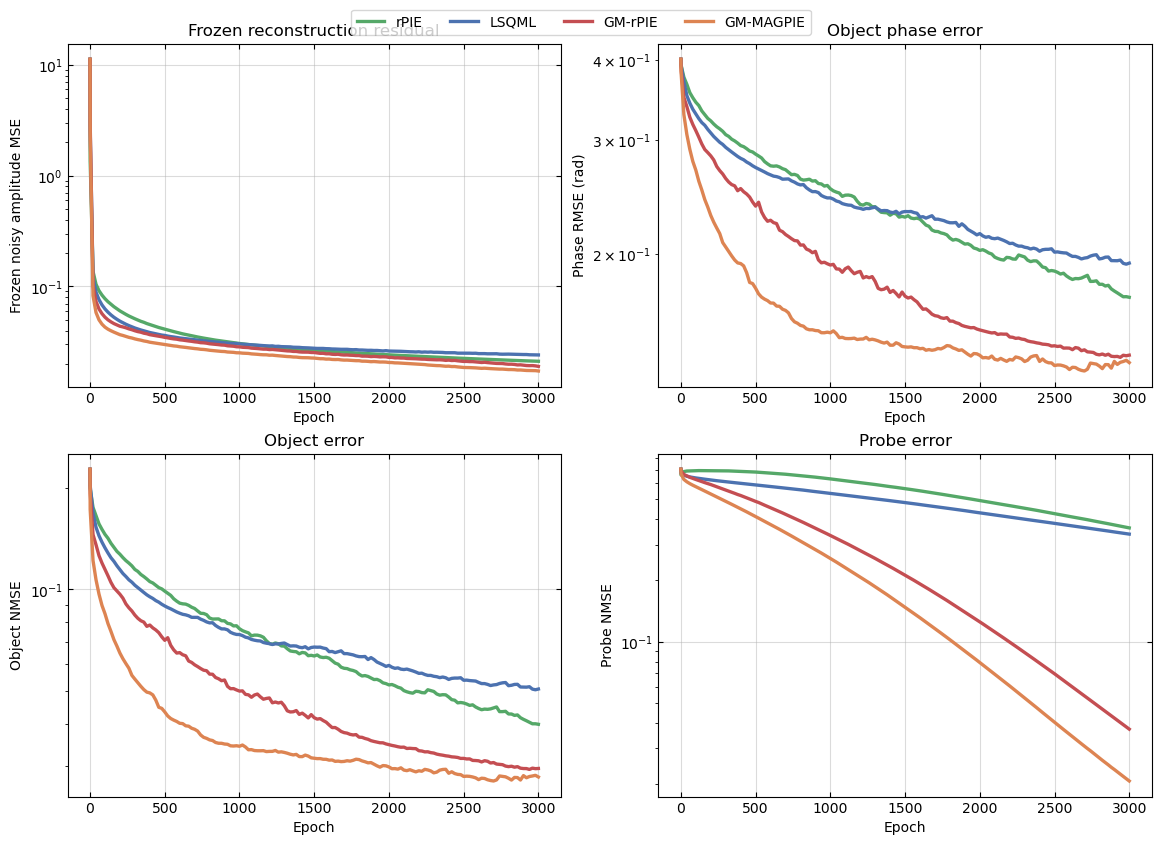

In [33]:
methods = completed_methods()
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2), constrained_layout=True)
curve_specs = (
    (
        axes[0, 0],
        "Frozen reconstruction residual",
        "Frozen noisy amplitude MSE",
        FROZEN_NOISY_KEY,
    ),
    (axes[0, 1], "Object phase error", "Phase RMSE (rad)", "phase_rmse_rad"),
    (axes[1, 0], "Object error", "Object NMSE", "object_nmse"),
    (axes[1, 1], "Probe error", "Probe NMSE", "probe_nmse"),
)

for axis, title, ylabel, metric_name in curve_specs:
    for method_name in methods:
        result = results[method_name]
        values = result.metric_history[metric_name]
        valid = np.isfinite(values) & (values > 0)
        axis.semilogy(
            result.metric_epochs[valid],
            values[valid],
            linewidth=2.4,
            color=METHOD_COLORS[method_name],
            label=method_name,
        )
    axis.set(title=title, xlabel="Epoch", ylabel=ylabel)
    axis.grid(True, which="major", alpha=0.45)
    axis.grid(False, which="minor")
    axis.tick_params(direction="in", top=True, right=True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(methods),
    bbox_to_anchor=(0.5, 1.02),
)
plt.show()


## Object comparison


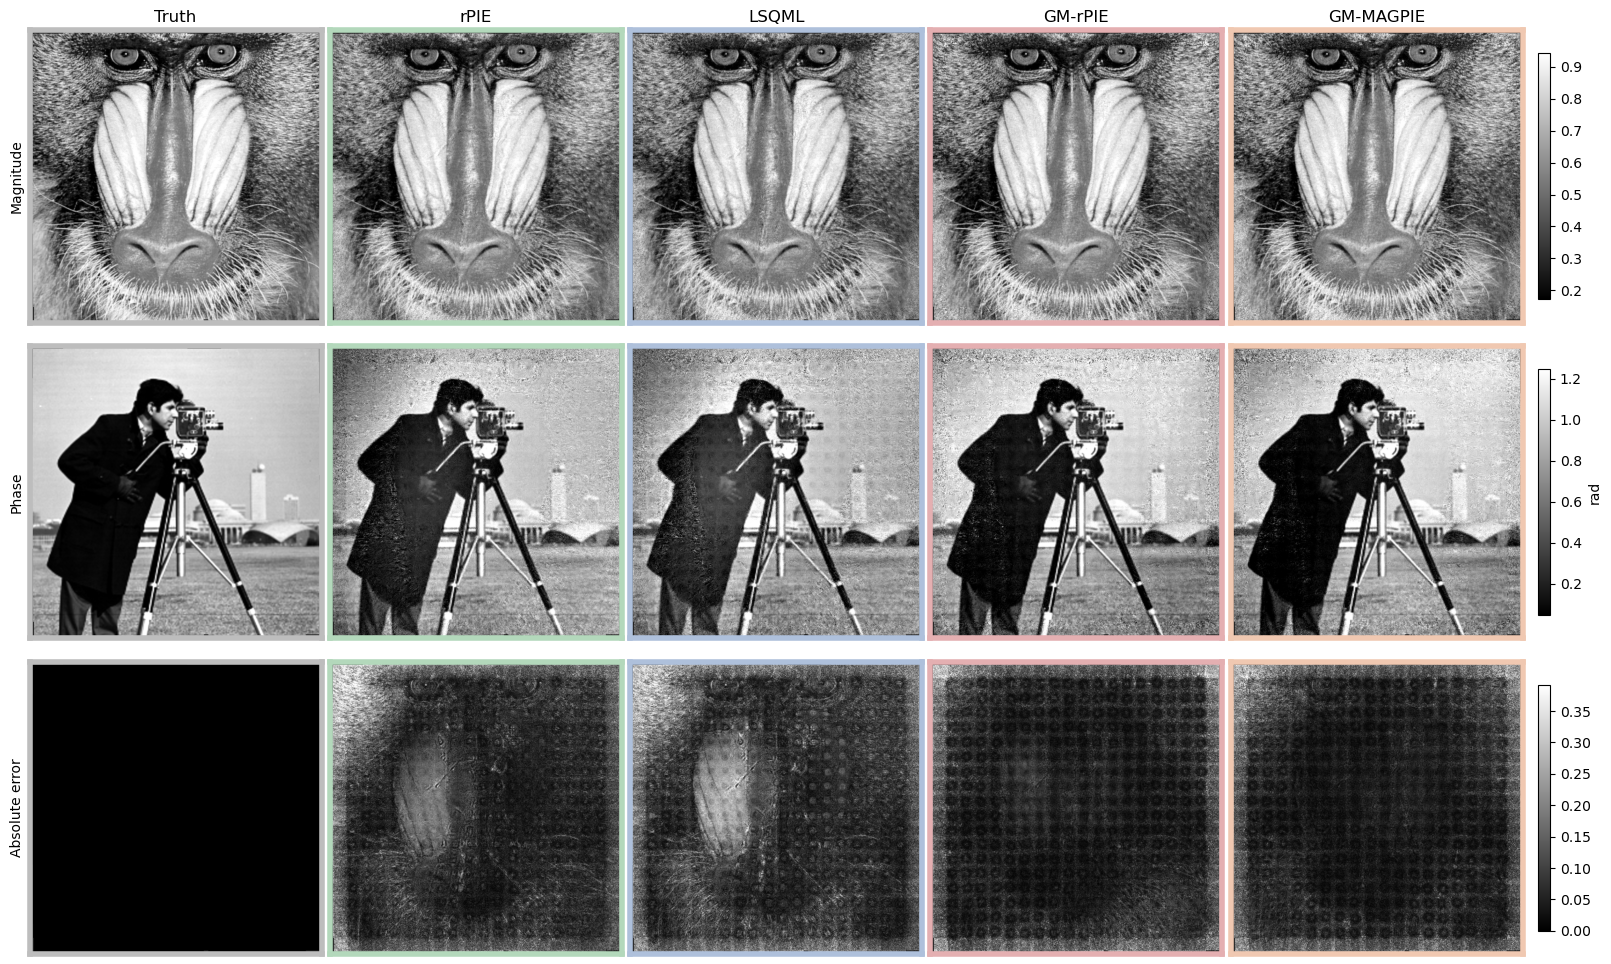

In [34]:
methods = [method for method in METHOD_ORDER if method in aligned_objects]
object_panels = {"Truth": registered_truth, **aligned_objects}
object_errors = {
    "Truth": np.zeros_like(np.abs(registered_truth), dtype=np.float32),
    **{
        method: np.abs(aligned_objects[method] - registered_truth)
        for method in methods
    },
}
magnitude_limits = robust_limits(
    np.abs(registered_truth[illuminated]),
    (1, 99),
    nonnegative=True,
)
phase_limits = robust_limits(np.angle(registered_truth[illuminated]), (1, 99))
error_max = robust_limits(
    np.concatenate([object_errors[method][illuminated] for method in methods]),
    (0, 99),
    nonnegative=True,
)[1]
object_cmap = plt.colormaps["gray"].copy()
object_cmap.set_bad("#202020")

fig, axes = plt.subplots(
    3,
    len(object_panels),
    figsize=(3.2 * len(object_panels), 9.6),
    constrained_layout=True,
    squeeze=False,
)
for column, (name, object_value) in enumerate(object_panels.items()):
    magnitude_image = axes[0, column].imshow(
        np.ma.array(np.abs(object_value), mask=~illuminated),
        cmap=object_cmap,
        vmin=magnitude_limits[0],
        vmax=magnitude_limits[1],
    )
    phase_image = axes[1, column].imshow(
        np.ma.array(np.angle(object_value), mask=~illuminated),
        cmap=object_cmap,
        vmin=phase_limits[0],
        vmax=phase_limits[1],
    )
    error_image = axes[2, column].imshow(
        np.ma.array(object_errors[name], mask=~illuminated),
        cmap=object_cmap,
        vmin=0.0,
        vmax=error_max,
    )
    axes[0, column].set_title(name)
    for row in range(3):
        axis = axes[row, column]
        axis.set(xticks=[], yticks=[])
        for spine in axis.spines.values():
            spine.set_color(PANEL_FRAME_COLORS[name])
            spine.set_linewidth(4.0)

axes[0, 0].set_ylabel("Magnitude")
axes[1, 0].set_ylabel("Phase")
axes[2, 0].set_ylabel("Absolute error")
fig.colorbar(magnitude_image, ax=axes[0, :], shrink=0.8, pad=0.01)
fig.colorbar(phase_image, ax=axes[1, :], shrink=0.8, pad=0.01, label="rad")
fig.colorbar(error_image, ax=axes[2, :], shrink=0.8, pad=0.01)
plt.show()


## Probe comparison


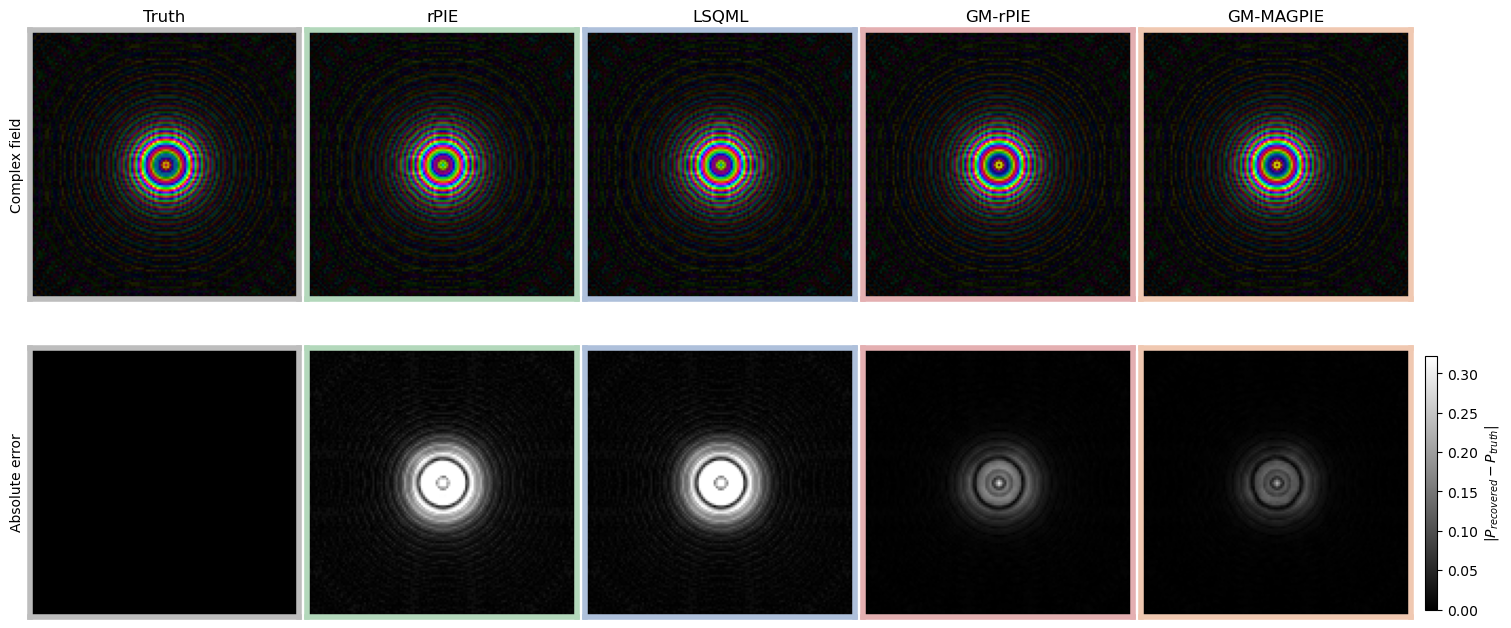

In [35]:
methods = [method for method in METHOD_ORDER if method in aligned_probes]
probe_panels = {"Truth": dataset.probe_truth, **aligned_probes}
probe_errors = {
    "Truth": np.zeros_like(np.abs(dataset.probe_truth), dtype=np.float32),
    **{
        method: np.abs(aligned_probes[method] - dataset.probe_truth)
        for method in methods
    },
}
magnitude_max = robust_limits(
    np.concatenate([np.abs(value).ravel() for value in probe_panels.values()]),
    (0, 99.8),
    nonnegative=True,
)[1]
error_max = robust_limits(
    np.concatenate([probe_errors[method].ravel() for method in methods]),
    (0, 99),
    nonnegative=True,
)[1]

fig, axes = plt.subplots(
    2,
    len(probe_panels),
    figsize=(3.0 * len(probe_panels), 6.4),
    constrained_layout=True,
    squeeze=False,
)
for column, (name, probe_value) in enumerate(probe_panels.items()):
    axes[0, column].imshow(complex_to_rgb(probe_value, magnitude_max))
    error_image = axes[1, column].imshow(
        probe_errors[name],
        cmap="gray",
        vmin=0.0,
        vmax=error_max,
    )
    axes[0, column].set_title(name)
    for row in range(2):
        axis = axes[row, column]
        axis.set(xticks=[], yticks=[])
        axis.set_facecolor("black")
        for spine in axis.spines.values():
            spine.set_color(PANEL_FRAME_COLORS[name])
            spine.set_linewidth(4.0)

axes[0, 0].set_ylabel("Complex field")
axes[1, 0].set_ylabel("Absolute error")
fig.colorbar(
    error_image,
    ax=axes[1, :],
    shrink=0.82,
    pad=0.01,
    label=r"$|P_{recovered} - P_{truth}|$",
)
plt.show()
